# Generate Dataset for Benchmarks

Requirements:
- Query niches * 3 (multi parcellations from different sample)
- Target niches (sigmoid RM-ideal scores) on all 16 samples (from different labs)

In [ ]:
import logging

# sys.path.insert(0, str(Path.cwd().parent.parent / "src"))
logging.basicConfig(level=logging.INFO)

## Explore Query Niches

In [2]:
from src.NicheQueryPrototype.database import Database
from src.NicheQueryPrototype.niche import Niche
from src.NicheQueryPrototype.query import NicheQuery

# step 1: create db
zhuang_abca_1_folder = 'notebook/ccf/data/zhuang-abca-1/'
zhuang_abca_2_folder = 'notebook/ccf/data/zhuang-abca-2/'
zhuang_abca_3_folder = 'notebook/ccf/data/zhuang-abca-3/'
zeng_mwb_folder = 'notebook/ccf/data/zeng-mwb/'
sample_data_folder = 'notebook/ccf/data/benchmark_samples/20260414_235933'

target_sample_ids = [
    'Zhuang-ABCA-1.098', 'Zhuang-ABCA-1.099', 'Zhuang-ABCA-1.097', 'Zhuang-ABCA-1.096',
    # 'Zhuang-ABCA-2.046', 'Zhuang-ABCA-2.047', 'Zhuang-ABCA-2.048', #'Zhuang-ABCA-2.050',
    'Zhuang-ABCA-3.001', 'Zhuang-ABCA-3.002', 'Zhuang-ABCA-3.004', 'Zhuang-ABCA-3.005',
    'C57BL6J-638850.28', 'C57BL6J-638850.29', 'C57BL6J-638850.30', 'C57BL6J-638850.31'
]
rm_ideal_output_key = "rm_ideal_score"

db = Database(target_sample_ids)

db.construct(
    adata_path=[
        sample_data_folder + '/' + sample_id + '.h5ad'
        for sample_id in target_sample_ids
    ],
    cell_metadata_path=[
        zhuang_abca_1_folder + 'cell_metadata.csv',
        zhuang_abca_2_folder + 'cell_metadata.csv',
        zhuang_abca_3_folder + 'cell_metadata.csv',
        zeng_mwb_folder + 'cell_metadata.csv',
    ],
    ccf_coordinates_path=[
        zhuang_abca_1_folder + 'ccf_coordinates.csv',
        zhuang_abca_2_folder + 'ccf_coordinates.csv',
        zhuang_abca_3_folder + 'ccf_coordinates.csv',
        zeng_mwb_folder + 'ccf_coordinates.csv',
    ],
    feature_name='gene_expression',
    parcellation_path='notebook/ccf/data/parcellation/structure.json',
    rm_ideal_output_key=rm_ideal_output_key
)


/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:src.NicheQueryPrototype.database:Loading cell metadata...
INFO:src.NicheQueryPrototype.database:Loading CCF coordinates...
/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/database.py:373: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, chunksize=_METADATA_CSV_CHUNKSIZE):
/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/database.py:373: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, chunk

### 1. Parcellation 207-123 on Zhuang-ABCA-1

In [22]:
# Find query niche: try every parcellation-207 cell as center; stop when niche is 40–60% parcellation 123

import logging
_loggers = [
    logging.getLogger("src.NicheQueryPrototype.niche"),
    logging.getLogger("src.NicheQueryPrototype.database"),
]
_prev = [lg.level for lg in _loggers]
for lg in _loggers:
    lg.setLevel(logging.WARNING)

PARC_207, PARC_123 = 207, 123
PCT_LO, PCT_HI = 0.40, 0.60
K_HOP, CELL_LIMIT = 10, 100
ALLOWED_PARCELLATIONS = [PARC_207, PARC_123]
NICHE_NAME = "query_niche_207_123"

try:
    for query_niche_sample_id in target_sample_ids:
        print(query_niche_sample_id)
        if 'Zhuang-ABCA-1' not in query_niche_sample_id:
            continue

        sample = db.get_sample(query_niche_sample_id)
        if sample is None:
            raise ValueError(f"Sample not in db: {query_niche_sample_id!r}")

        cells_207 = [c for c in sample.cells if c.parcellation_index == PARC_207]
        print(
            f"Sample {query_niche_sample_id!r}: {len(cells_207)} cells with "
            f"parcellation_index={PARC_207}"
        )

        niche_to_query = None
        matched_center_id = None
        best_near = None  # (dist, center, frac_123, n, n_207, n_123)

        for i, center in enumerate(cells_207):
            trial = Niche()
            trial.construct_by_k_hop(
                db,
                center_cell_id=str(center.id),
                sample_id=query_niche_sample_id,
                k=K_HOP,
                cell_limit=CELL_LIMIT,
                parcellation_index=ALLOWED_PARCELLATIONS,
            )
            n = len(trial.cells)
            n_123 = sum(1 for c in trial.cells if c.parcellation_index == PARC_123)
            n_207 = sum(1 for c in trial.cells if c.parcellation_index == PARC_207)
            frac_123 = n_123 / n if n else 0.0

            if PCT_LO <= frac_123 <= PCT_HI:
                dist = 0.0
            else:
                dist = min(abs(frac_123 - PCT_LO), abs(frac_123 - PCT_HI))
            if best_near is None or dist < best_near[0]:
                best_near = (dist, center, frac_123, n, n_207, n_123)

            if (i + 1) % 25 == 0 or PCT_LO <= frac_123 <= PCT_HI:
                print(
                    f"  [{i + 1}/{len(cells_207)}] center={center.id}  "
                    f"n={n}  207={n_207}  123={n_123}  frac_123={frac_123:.3f}"
                )

            if PCT_LO <= frac_123 <= PCT_HI:
                matched_center_id = str(center.id)
                niche_to_query = Niche()
                niche_to_query.construct_by_k_hop(
                    db,
                    center_cell_id=matched_center_id,
                    sample_id=query_niche_sample_id,
                    k=K_HOP,
                    cell_limit=CELL_LIMIT,
                    parcellation_index=ALLOWED_PARCELLATIONS,
                    niche_name=NICHE_NAME,
                )
                print(
                    f"\nSTOP: sample = {sample_id}\n frac_123={frac_123:.3f} in [{PCT_LO:.0%}, {PCT_HI:.0%}]\n"
                    f"  center_cell_id={matched_center_id}\n"
                    f"  niche n={len(niche_to_query.cells)}  "
                    f"207={n_207}  123={n_123}"
                )
                break

        if niche_to_query is None:
            _, center, frac, n, n_207, n_123 = best_near
            print(
                f"\nNo center with {PCT_LO:.0%} <= frac_123 <= {PCT_HI:.0%} "
                f"among {len(cells_207)} cells."
            )
            print(
                f"Closest: center={center.id}  n={n}  207={n_207}  123={n_123}  "
                f"frac_123={frac:.3f}"
            )
    pass
finally:
    for lg, prev in zip(_loggers, _prev):
        lg.setLevel(prev)

Zhuang-ABCA-1.098
Sample 'Zhuang-ABCA-1.098': 583 cells with parcellation_index=207
  [1/583] center=108395091855643956884780052311839360855  n=100  207=44  123=56  frac_123=0.560

STOP: sample = C57BL6J-638850.31
 frac_123=0.560 in [40%, 60%]
  center_cell_id=108395091855643956884780052311839360855
  niche n=100  207=44  123=56
Zhuang-ABCA-1.099
Sample 'Zhuang-ABCA-1.099': 462 cells with parcellation_index=207
  [1/462] center=107866618339577374843073403153303495275  n=100  207=54  123=46  frac_123=0.460

STOP: sample = C57BL6J-638850.31
 frac_123=0.460 in [40%, 60%]
  center_cell_id=107866618339577374843073403153303495275
  niche n=100  207=54  123=46
Zhuang-ABCA-1.097
Sample 'Zhuang-ABCA-1.097': 451 cells with parcellation_index=207
  [25/451] center=32778236969080438424784836940213625963  n=100  207=89  123=11  frac_123=0.110
  [50/451] center=745699380012673406833508435574012418  n=100  207=83  123=17  frac_123=0.170
  [75/451] center=34913012215333934173485805557786900371  n=100 

INFO:src.NicheQueryPrototype.niche:Constructing k-hop graph..
INFO:src.NicheQueryPrototype.niche:Computing niche feature..
INFO:src.NicheQueryPrototype.niche:Finished computing niche feature with 100 cells on Zhuang-ABCA-1.096 slice.
INFO:src.NicheQueryPrototype.niche:Wrote niche membership to adata.obsm['query_niche_207_123'] (n_in_niche=100, n_obs=28208).
INFO:src.NicheQueryPrototype.niche:Niche contains 100 cell(s) (sample_id='Zhuang-ABCA-1.096')
/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/niche.py:316: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


Niche cells by parcellation (n_total=100):
  parcellation_index=123  parcellation_name='Koelliker-Fuse subnucleus'  n_cells=54
  parcellation_index=207  parcellation_name='Area postrema'  n_cells=46


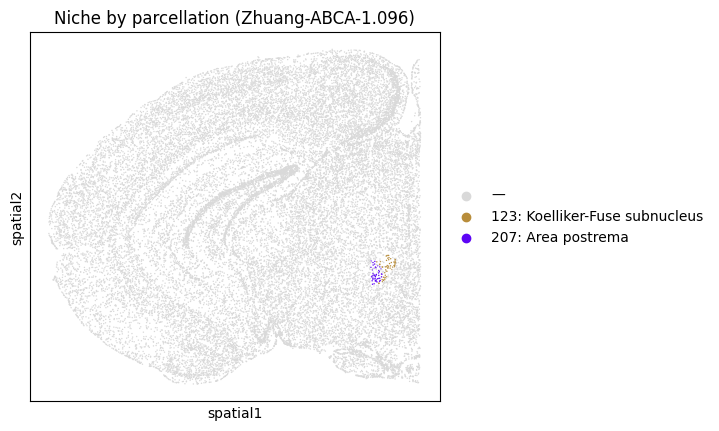

/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/niche.py:338: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


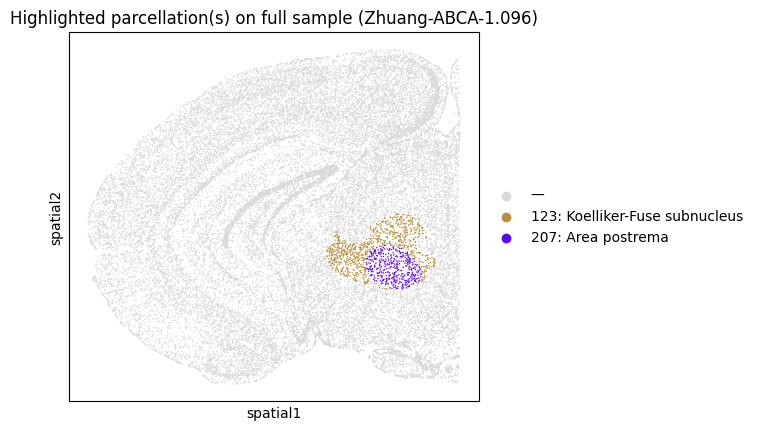

In [23]:
# Visualize the niche to query

query_niche_sample_id = 'Zhuang-ABCA-1.096'

niche_to_query = Niche()
niche_to_query.construct_by_k_hop(db, center_cell_id='115873764268629722312182509357101936308', sample_id=query_niche_sample_id, \
    k=10, cell_limit=100, parcellation_index=[207,123], niche_name='query_niche_207_123')
niche_to_query.visualize(db)

INFO:src.NicheQueryPrototype.niche:Constructing k-hop graph..
INFO:src.NicheQueryPrototype.niche:Computing niche feature..
INFO:src.NicheQueryPrototype.niche:Finished computing niche feature with 100 cells on Zhuang-ABCA-1.097 slice.
INFO:src.NicheQueryPrototype.niche:Wrote niche membership to adata.obsm['query_niche_207_123'] (n_in_niche=100, n_obs=25765).
INFO:src.NicheQueryPrototype.niche:Niche contains 100 cell(s) (sample_id='Zhuang-ABCA-1.097')
/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/niche.py:316: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


Niche cells by parcellation (n_total=100):
  parcellation_index=123  parcellation_name='Koelliker-Fuse subnucleus'  n_cells=43
  parcellation_index=207  parcellation_name='Area postrema'  n_cells=57


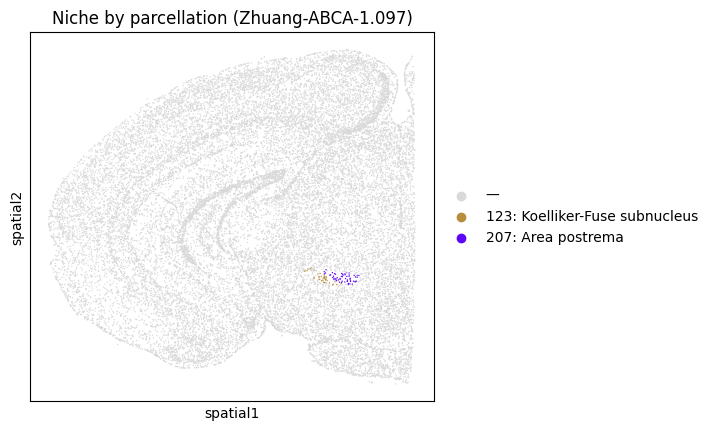

/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/niche.py:338: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


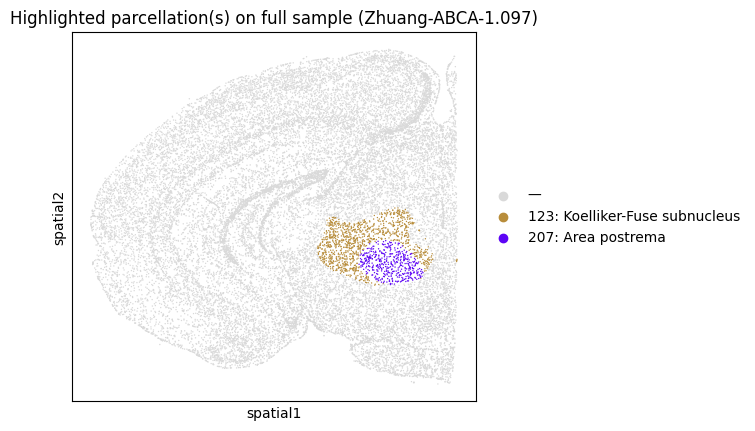

In [24]:
# Visualize the niche to query

query_niche_sample_id = 'Zhuang-ABCA-1.097'

niche_to_query = Niche()
niche_to_query.construct_by_k_hop(db, center_cell_id='284896277831894781863454227616495127602', sample_id=query_niche_sample_id, \
    k=10, cell_limit=100, parcellation_index=[207,123], niche_name='query_niche_207_123')
niche_to_query.visualize(db)

INFO:src.NicheQueryPrototype.niche:Constructing k-hop graph..
INFO:src.NicheQueryPrototype.niche:Computing niche feature..
INFO:src.NicheQueryPrototype.niche:Finished computing niche feature with 100 cells on Zhuang-ABCA-1.098 slice.
INFO:src.NicheQueryPrototype.niche:Wrote niche membership to adata.obsm['query_niche_207_123'] (n_in_niche=100, n_obs=26487).
INFO:src.NicheQueryPrototype.niche:Niche contains 100 cell(s) (sample_id='Zhuang-ABCA-1.098')
/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/niche.py:316: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


Niche cells by parcellation (n_total=100):
  parcellation_index=123  parcellation_name='Koelliker-Fuse subnucleus'  n_cells=60
  parcellation_index=207  parcellation_name='Area postrema'  n_cells=40


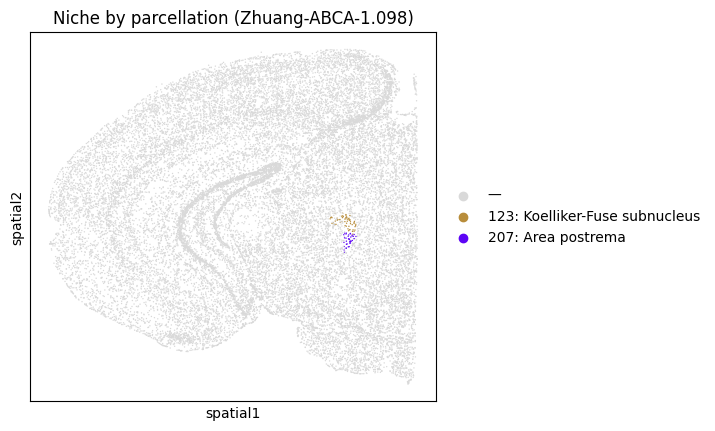

/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/niche.py:338: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


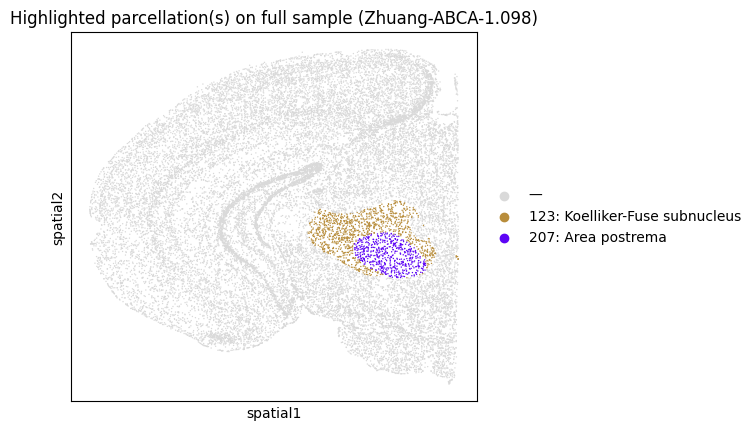

In [4]:
# Visualize the niche to query

query_niche_sample_id = 'Zhuang-ABCA-1.098'

niche_to_query = Niche()
niche_to_query.construct_by_k_hop(db, center_cell_id='337502760026487302083958961400454036056', sample_id=query_niche_sample_id, \
    k=10, cell_limit=100, parcellation_index=[207,123], niche_name='query_niche_207_123')
niche_to_query.visualize(db)

INFO:src.NicheQueryPrototype.niche:Constructing k-hop graph..
INFO:src.NicheQueryPrototype.niche:Computing niche feature..
INFO:src.NicheQueryPrototype.niche:Finished computing niche feature with 100 cells on Zhuang-ABCA-1.099 slice.
INFO:src.NicheQueryPrototype.niche:Wrote niche membership to adata.obsm['query_niche_207_123'] (n_in_niche=100, n_obs=27369).
INFO:src.NicheQueryPrototype.niche:Niche contains 100 cell(s) (sample_id='Zhuang-ABCA-1.099')
/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/niche.py:316: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


Niche cells by parcellation (n_total=100):
  parcellation_index=123  parcellation_name='Koelliker-Fuse subnucleus'  n_cells=46
  parcellation_index=207  parcellation_name='Area postrema'  n_cells=54


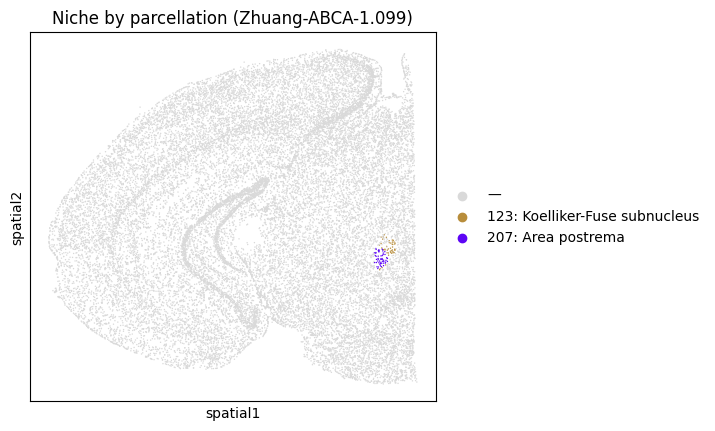

/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/niche.py:338: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


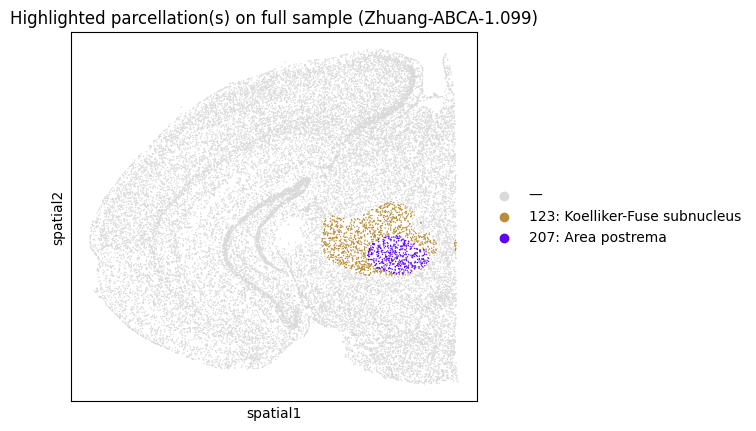

In [25]:
# Visualize the niche to query

query_niche_sample_id = 'Zhuang-ABCA-1.099'

niche_to_query = Niche()
niche_to_query.construct_by_k_hop(db, center_cell_id='107866618339577374843073403153303495275', sample_id=query_niche_sample_id, \
    k=10, cell_limit=100, parcellation_index=[207,123], niche_name='query_niche_207_123')
niche_to_query.visualize(db)

/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_99544/1074712895.py:94: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


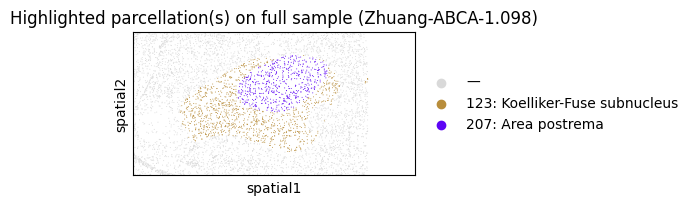

/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_99544/1074712895.py:94: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


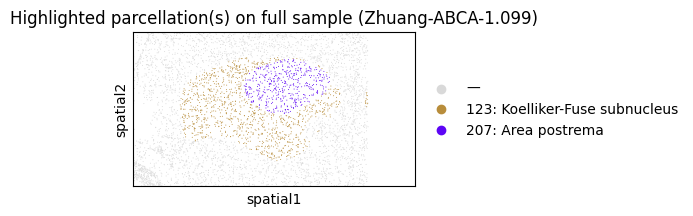

/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_99544/1074712895.py:94: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


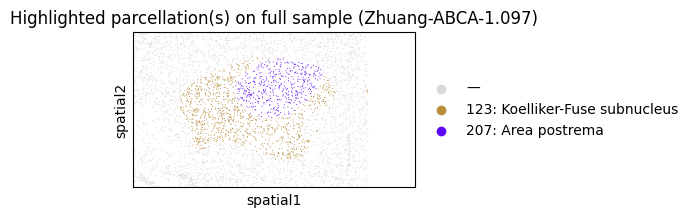

/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_99544/1074712895.py:94: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


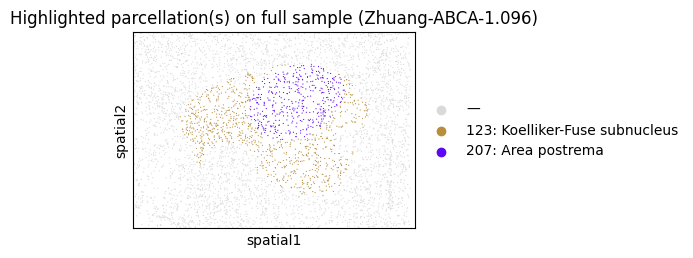

/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_99544/1074712895.py:94: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


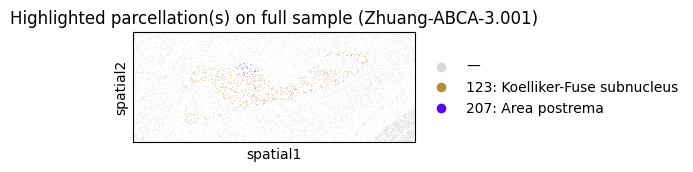

/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_99544/1074712895.py:94: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


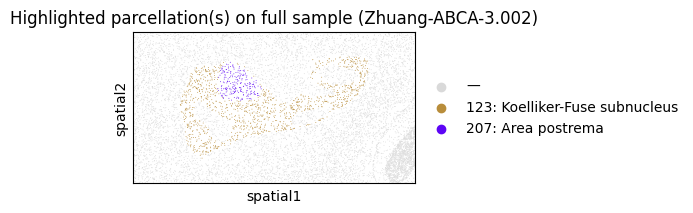

/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_99544/1074712895.py:94: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


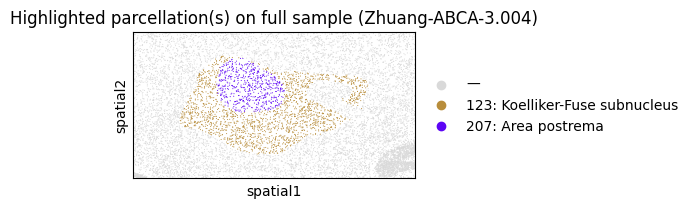

/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_99544/1074712895.py:94: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


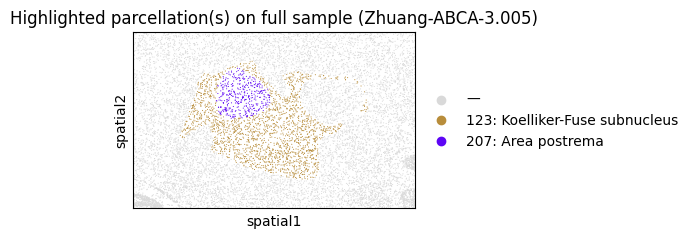

/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_99544/1074712895.py:94: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


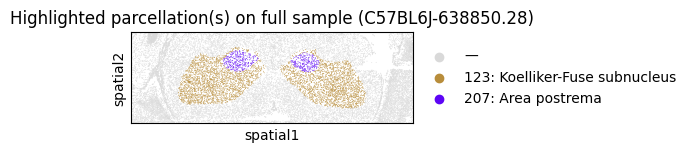

/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_99544/1074712895.py:94: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


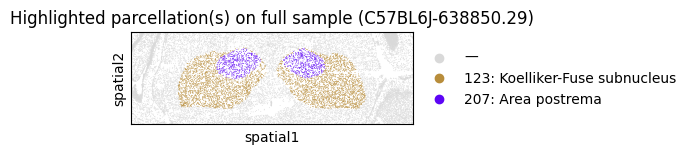

/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_99544/1074712895.py:94: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


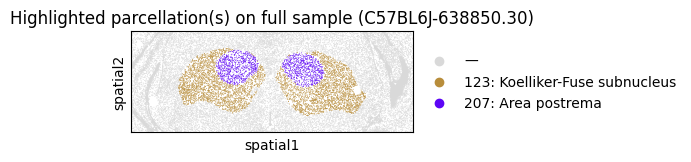

/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_99544/1074712895.py:94: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


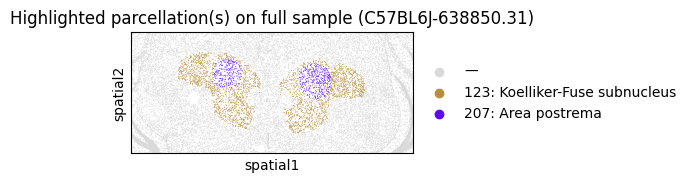

In [15]:
# Visualize query parcellations on each sample (one figure per sample, same style as niche_to_query.visualize)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.neighbors import NearestNeighbors

from src.NicheQueryPrototype.niche import (
    _distinct_category_hexes,
    _niche_highlight_parcellation_set,
    _parcellation_display_label,
)


def _zoom_limits_xy(coords, *, pad_frac=0.25, min_span_frac=0.12):
    if coords.size == 0:
        return None
    xs, ys = coords[:, 0], coords[:, 1]
    xmin, xmax = float(xs.min()), float(xs.max())
    ymin, ymax = float(ys.min()), float(ys.max())
    raw_dx, raw_dy = max(xmax - xmin, 0.0), max(ymax - ymin, 0.0)
    span = max(raw_dx, raw_dy)
    if span <= 0:
        eps = max(abs(xmin), abs(ymin), 1e-4) * 0.05
        return (xmin - eps, xmax + eps), (ymin - eps, ymax + eps)
    min_span = max(span * min_span_frac, span * 0.02, 1e-9)
    dx, dy = max(raw_dx, min_span), max(raw_dy, min_span)
    cx, cy = (xmin + xmax) / 2, (ymin + ymax) / 2
    pad_x, pad_y = dx * pad_frac, dy * pad_frac
    return (cx - dx / 2 - pad_x, cx + dx / 2 + pad_x), (cy - dy / 2 - pad_y, cy + dy / 2 + pad_y)


def _adaptive_spot_size(coords, *, nn_fraction=0.45, lo=1e-4, hi=2.0):
    if coords.shape[0] < 2:
        return 0.02
    sub = coords
    if sub.shape[0] > 500:
        sub = sub[np.random.default_rng(0).choice(sub.shape[0], 500, replace=False)]
    dists, _ = NearestNeighbors(n_neighbors=2).fit(sub).kneighbors(sub)
    med = float(np.median(dists[:, 1]))
    if not np.isfinite(med) or med <= 0:
        xs, ys = sub[:, 0], sub[:, 1]
        area = max(float((xs.max() - xs.min()) * (ys.max() - ys.min())), 1e-12)
        med = float(np.sqrt(area / sub.shape[0]))
    return float(np.clip(nn_fraction * med, lo, hi))


highlight_pidx = _niche_highlight_parcellation_set(niche_to_query)
highlight_sorted = sorted(highlight_pidx)

pidx_to_label = {}
for p in highlight_sorted:
    rep = next(
        (c for s in db.samples.values() for c in s.cells if c.parcellation_index == p),
        None,
    )
    pidx_to_label[p] = (
        _parcellation_display_label(rep) if rep is not None else str(p)
    )

categories = ["—"] + [pidx_to_label[p] for p in highlight_sorted]
palette = ["#d9d9d9"] + _distinct_category_hexes(len(highlight_sorted))

spot_size_scale = 0.45  # lower = smaller dots
zoom_pad_frac = 0.25

for sample_id in target_sample_ids:
    sample = db.get_sample(sample_id)
    if sample is None:
        continue

    id_to_cell = {str(c.id): c for c in sample.cells}
    labels = []
    for oid in sample.adata.obs_names:
        cf = id_to_cell.get(str(oid))
        if cf is None or cf.parcellation_index not in highlight_pidx:
            labels.append("—")
        else:
            labels.append(pidx_to_label[cf.parcellation_index])

    sample.adata.obs["sample_parcellation_index"] = pd.Categorical(
        labels, categories=categories
    )

    highlight_coords = np.array(
        [[c.x, c.y] for c in sample.cells if c.parcellation_index in highlight_pidx],
        dtype=float,
    )
    n_hl = highlight_coords.shape[0]
    spot_size = _adaptive_spot_size(highlight_coords, nn_fraction=spot_size_scale) if n_hl else 0.02

    fig, ax = plt.subplots(figsize=(6, 6))
    sc.pl.spatial(
        sample.adata,
        color="sample_parcellation_index",
        palette=palette,
        ax=ax,
        show=False,
        spot_size=spot_size,
        title=f"Highlighted parcellation(s) on full sample ({sample.id})",
    )
    if n_hl:
        limits = _zoom_limits_xy(highlight_coords, pad_frac=zoom_pad_frac)
        if limits is not None:
            (x0, x1), (y0, y1) = limits
            ax.set_xlim(x0, x1)
            ax.set_ylim(y0, y1)
        ax.set_aspect("equal", adjustable="box")

    plt.tight_layout()
    plt.show()


### 2. Parcellation 610-824-353 on Zhuang-ABCA-3

In [ ]:
# Find query niche: try every parcellation-610 cell as center;
# stop when niche has 100 cells and counts for 610, 824, 353 are roughly equal (±10%).

import logging
from collections import Counter

_loggers = [
    logging.getLogger("src.NicheQueryPrototype.niche"),
    logging.getLogger("src.NicheQueryPrototype.database"),
]
_prev = [lg.level for lg in _loggers]
for lg in _loggers:
    lg.setLevel(logging.WARNING)

PARC_610, PARC_824, PARC_353 = 610, 824, 353
PARCELLATIONS = [PARC_610, PARC_824, PARC_353]
REL_TOL = 0.10
K_HOP, CELL_LIMIT = 10, 100
ALLOWED_PARCELLATIONS = PARCELLATIONS
NICHE_NAME = "query_niche_610_824_353"
QUERY_NICHE_SAMPLE_IDS = [
    "Zhuang-ABCA-3.001",
    "Zhuang-ABCA-3.002",
    "Zhuang-ABCA-3.004",
    "Zhuang-ABCA-3.005",
]


def _parcellation_counts(cells):
    cnt = Counter(c.parcellation_index for c in cells)
    return {p: cnt.get(p, 0) for p in PARCELLATIONS}


def _counts_balanced(counts, *, n_cells):
    if n_cells != CELL_LIMIT:
        return False
    if any(counts[p] == 0 for p in PARCELLATIONS):
        return False
    avg = n_cells / len(PARCELLATIONS)
    return all(abs(counts[p] - avg) / avg <= REL_TOL for p in PARCELLATIONS)


def _imbalance_score(counts):
    vals = [counts[p] for p in PARCELLATIONS]
    avg = sum(vals) / len(vals)
    if avg == 0:
        return float("inf")
    return max(abs(v - avg) / avg for v in vals)


try:
    for query_niche_sample_id in QUERY_NICHE_SAMPLE_IDS:
        print(query_niche_sample_id)

        sample = db.get_sample(query_niche_sample_id)
        if sample is None:
            raise ValueError(f"Sample not in db: {query_niche_sample_id!r}")

        avail = _parcellation_counts(sample.cells)
        print(
            f"Sample {query_niche_sample_id!r}: cells with target parcellations "
            f"610={avail[PARC_610]}  824={avail[PARC_824]}  353={avail[PARC_353]}"
        )

        cells_610 = [c for c in sample.cells if c.parcellation_index == PARC_610]
        print(f"  trying {len(cells_610)} parcellation-610 center(s)")

        niche_to_query = None
        matched_center_id = None
        best_near = None  # (imbalance, center, counts, n)

        for i, center in enumerate(cells_610):
            trial = Niche()
            trial.construct_by_k_hop(
                db,
                center_cell_id=str(center.id),
                sample_id=query_niche_sample_id,
                k=K_HOP,
                cell_limit=CELL_LIMIT,
                parcellation_index=ALLOWED_PARCELLATIONS,
            )
            n = len(trial.cells)
            counts = _parcellation_counts(trial.cells)
            balanced = _counts_balanced(counts, n_cells=n)
            imb = _imbalance_score(counts)

            if best_near is None or imb < best_near[0]:
                best_near = (imb, center, counts, n)

            if (i + 1) % 25 == 0 or balanced:
                print(
                    f"  [{i + 1}/{len(cells_610)}] center={center.id}  "
                    f"n={n}  610={counts[PARC_610]}  824={counts[PARC_824]}  "
                    f"353={counts[PARC_353]}  imbalance={imb:.3f}"
                )

            if balanced:
                matched_center_id = str(center.id)
                niche_to_query = Niche()
                niche_to_query.construct_by_k_hop(
                    db,
                    center_cell_id=matched_center_id,
                    sample_id=query_niche_sample_id,
                    k=K_HOP,
                    cell_limit=CELL_LIMIT,
                    parcellation_index=ALLOWED_PARCELLATIONS,
                    niche_name=NICHE_NAME,
                )
                print(
                    f"\nSTOP: sample = {query_niche_sample_id}\n"
                    f"  counts within ±{REL_TOL:.0%} of equal split\n"
                    f"  center_cell_id={matched_center_id}\n"
                    f"  niche n={len(niche_to_query.cells)}  "
                    f"610={counts[PARC_610]}  824={counts[PARC_824]}  "
                    f"353={counts[PARC_353]}"
                )
                break

        if niche_to_query is None:
            imb, center, counts, n = best_near
            print(
                f"\nNo center with balanced 610/824/353 counts among "
                f"{len(cells_610)} parcellation-610 cells."
            )
            print(
                f"Closest: center={center.id}  n={n}  "
                f"610={counts[PARC_610]}  824={counts[PARC_824]}  "
                f"353={counts[PARC_353]}  imbalance={imb:.3f}"
            )
finally:
    for lg, prev in zip(_loggers, _prev):
        lg.setLevel(prev)


### 3. Parcellation 9-15 on C57BL6J-638850

In [ ]:
# Find query niche: try every parcellation-9 cell as center; stop when niche is 40–60% parcellation 15

import logging
_loggers = [
    logging.getLogger("src.NicheQueryPrototype.niche"),
    logging.getLogger("src.NicheQueryPrototype.database"),
]
_prev = [lg.level for lg in _loggers]
for lg in _loggers:
    lg.setLevel(logging.WARNING)

PARC_9, PARC_15 = 9, 15
PCT_LO, PCT_HI = 0.40, 0.60
K_HOP, CELL_LIMIT = 10, 100
ALLOWED_PARCELLATIONS = [PARC_9, PARC_15]
NICHE_NAME = "query_niche_9_15"
QUERY_NICHE_SAMPLE_IDS = [
    'C57BL6J-638850.28', 'C57BL6J-638850.29',
    'C57BL6J-638850.30', 'C57BL6J-638850.31',
]

try:
    for query_niche_sample_id in QUERY_NICHE_SAMPLE_IDS:
        print(query_niche_sample_id)

        sample = db.get_sample(query_niche_sample_id)
        if sample is None:
            raise ValueError(f"Sample not in db: {query_niche_sample_id!r}")

        cells_9 = [c for c in sample.cells if c.parcellation_index == PARC_9]
        print(
            f"Sample {query_niche_sample_id!r}: {len(cells_9)} cells with "
            f"parcellation_index={PARC_9}"
        )

        niche_to_query = None
        matched_center_id = None
        best_near = None  # (dist, center, frac_15, n, n_9, n_15)

        for i, center in enumerate(cells_9):
            trial = Niche()
            trial.construct_by_k_hop(
                db,
                center_cell_id=str(center.id),
                sample_id=query_niche_sample_id,
                k=K_HOP,
                cell_limit=CELL_LIMIT,
                parcellation_index=ALLOWED_PARCELLATIONS,
            )
            n = len(trial.cells)
            n_9 = sum(1 for c in trial.cells if c.parcellation_index == PARC_9)
            n_15 = sum(1 for c in trial.cells if c.parcellation_index == PARC_15)
            frac_15 = n_15 / n if n else 0.0

            if PCT_LO <= frac_15 <= PCT_HI:
                dist = 0.0
            else:
                dist = min(abs(frac_15 - PCT_LO), abs(frac_15 - PCT_HI))
            if best_near is None or dist < best_near[0]:
                best_near = (dist, center, frac_15, n, n_9, n_15)

            if (i + 1) % 25 == 0 or PCT_LO <= frac_15 <= PCT_HI:
                print(
                    f"  [{i + 1}/{len(cells_9)}] center={center.id}  "
                    f"n={n}  9={n_9}  15={n_15}  frac_15={frac_15:.3f}"
                )

            if PCT_LO <= frac_15 <= PCT_HI:
                matched_center_id = str(center.id)
                niche_to_query = Niche()
                niche_to_query.construct_by_k_hop(
                    db,
                    center_cell_id=matched_center_id,
                    sample_id=query_niche_sample_id,
                    k=K_HOP,
                    cell_limit=CELL_LIMIT,
                    parcellation_index=ALLOWED_PARCELLATIONS,
                    niche_name=NICHE_NAME,
                )
                print(
                    f"\nSTOP: sample = {query_niche_sample_id}\n frac_15={frac_15:.3f} in [{PCT_LO:.0%}, {PCT_HI:.0%}]\n"
                    f"  center_cell_id={matched_center_id}\n"
                    f"  niche n={len(niche_to_query.cells)}  "
                    f"9={n_9}  15={n_15}"
                )
                break

        if niche_to_query is None:
            _, center, frac, n, n_9, n_15 = best_near
            print(
                f"\nNo center with {PCT_LO:.0%} <= frac_15 <= {PCT_HI:.0%} "
                f"among {len(cells_9)} cells."
            )
            print(
                f"Closest: center={center.id}  n={n}  9={n_9}  15={n_15}  "
                f"frac_15={frac:.3f}"
            )
finally:
    for lg, prev in zip(_loggers, _prev):
        lg.setLevel(prev)

## Export Benchmark Dataset

In [ ]:
# Add a layer for the query niches
# Add a layer for the RM scores for each query niche